In [3]:
from skimage.io import imread
import anndata 
from pathlib import Path
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



import tifffile
from tifffile import imread
from tqdm import tqdm


import sys
sys.path.append("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial")
sys.path.append("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src")
from NSCLCDataModule import NsclcImageDataset
%matplotlib inline

# Create toy dataset and initialize paths + getters

In [4]:
with open("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/val_tumor_typ_20250519.txt", "r") as file:
    val_ids = [line.strip().split("\t")[1] for line in file if line.strip()]

toy_dataset = NsclcImageDataset(
    patient_ids_array=val_ids[:int(len(val_ids) / 10)],
    use_sampler=False
)

Processing patients: 100%|██████████| 16/16 [00:07<00:00,  2.13it/s]

Memory usage 1026.77 MB, 


In [ ]:
toy_dataset[1]['imc_image']

{'id': 1,
 'patient_id': '175_A_15',
 'tumor_type': 'Adenocarcinoma',
 'imc_image': array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        ...,
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ..

In [7]:
for k in range(5):
    print(toy_dataset[k]['imc_image'].shape)

(43, 749, 724)
(43, 800, 742)
(43, 754, 709)
(43, 848, 742)
(43, 743, 697)


In [19]:
nsclc_path = Path('/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed')

mask_path = nsclc_path / 'masks/20250430_cell_masks'
anndata_base_path = nsclc_path / 'export/20250512_adata_graphs'
all_cells_anndata_path = nsclc_path / 'sce_objects/sce.h5ad'
metadata_path = nsclc_path / 'metadata/clinical.parquet'
img_path = nsclc_path / 'images/images_mcd'

df_metadata = pd.read_parquet(metadata_path)
        
def get_mask(patient_id):
    patient_mask_path = mask_path / f"{patient_id}.tiff"
    return imread(patient_mask_path)

def get_anndata(patient_id): 
    return anndata.read_h5ad(anndata_base_path / f'{patient_id}.h5ad')

def get_tumor_type(patient_id):
    return get_anndata(patient_id).obs['DX.name'].iloc[0]

def get_image(patient_id):
    patient_img_path = img_path / f"{patient_id}.tiff"
    return imread(patient_img_path)

In [3]:
im = get_image('175_C_121').astype(np.uint32)
mask = get_mask('175_C_121').astype(np.uint32)

In [15]:
import tifffile 

def get_dimensionality_reduction(from_aggregated=True, file_limit=None):
    def get_patient_id(img_path):
        # Convert Path object to string if needed
        img_path = str(img_path)
        return img_path.split("/")[-1].split(".")[0]
    
    # Define source directory based on the flag
    base_dir = Path('/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed')
    if from_aggregated:
        src_dir = base_dir / 'images/images_mcd_masked_averaged'
    else:
        src_dir = base_dir / 'images/images_mcd_masked'

    pixel_list = []
    
    # Check if directory exists
    if not src_dir.exists():
        raise FileNotFoundError(f"Directory not found: {src_dir}")
    
    # Iterate through image files in the directory
    for image_path in tqdm(src_dir.glob('*.tiff')):  # assuming they're TIFF files
        if file_limit is not None:
            if len(pixel_list) > file_limit:
                break

        try:
            image = tifffile.imread(image_path)
            patient_id = get_patient_id(image_path)  # pass image_path, not image
            mask = get_mask(patient_id).astype(np.uint32)  # assuming get_mask is defined elsewhere
            nonzero_indices = np.nonzero(mask)
            
            # Check if image and mask dimensions match
            if image.shape[1:] != mask.shape:
                raise ValueError(f"Image and mask dimensions don't match for {patient_id}")
            pixel_array = image[:, nonzero_indices[0], nonzero_indices[1]]
            indices = np.random.choice(pixel_array.shape[1], 1000, replace=False)

            pixel_list.append(pixel_array[:, indices])
        except Exception as e:
            print(f"Error processing {image_path}: {str(e)}")
            continue

    return np.concatenate(pixel_list, axis=1)

In [ ]:
pixel_list = get_dimensionality_reduction(from_aggregated=False)

In [3]:
df = pd.read_csv("panel.csv")
channel_map = list(df['Clean_Target'].dropna())



## Plot box and whixker plot for pixel_list

In [ ]:
# Generate example data if you don't have your own
# X should be a 2D numpy array with shape (n_features, n_samples)
np.random.seed(42)
X = pixel_list  # Random normal data
n_features = X.shape[0]
n_samples = X.shape[1]

# Create the box plot
plt.figure(figsize=(14, 7))  # Wider figure

# Transpose X so each row becomes a different box (feature)
box = plt.boxplot(
    X.T,
    tick_labels=[channel_map[i] for i in range(n_features)],
    showfliers=False,
    patch_artist=True,
)

# Customize the plot
plt.title('Box Plot of Protein Expressions', fontsize=14)
plt.xlabel('', fontsize=12)  # Empty since we have direct labels
plt.ylabel('Unnofmalized expression values', fontsize=12, labelpad=15)
# plt.xticks(np.arange(1, n_features+1), [f'Feature {i}' for i in range(1, n_features+1)])
# plt.grid(True, linestyle='--', alpha=0.7)

# Add more space between boxes if needed
positions = np.arange(1, n_features + 1)
plt.xlim(0.5, n_features + 0.5)  # Add padding on both sides

# Set vertical labels with proper alignment and spacing
plt.xticks(rotation=90, 
          fontsize=12,
          ha='right',  # Horizontal alignment centered
          va='center',  # Vertical alignment at bottom
          rotation_mode='anchor')  # Rotates around anchor point

plt.tight_layout()

plt.show()

(41,)
41


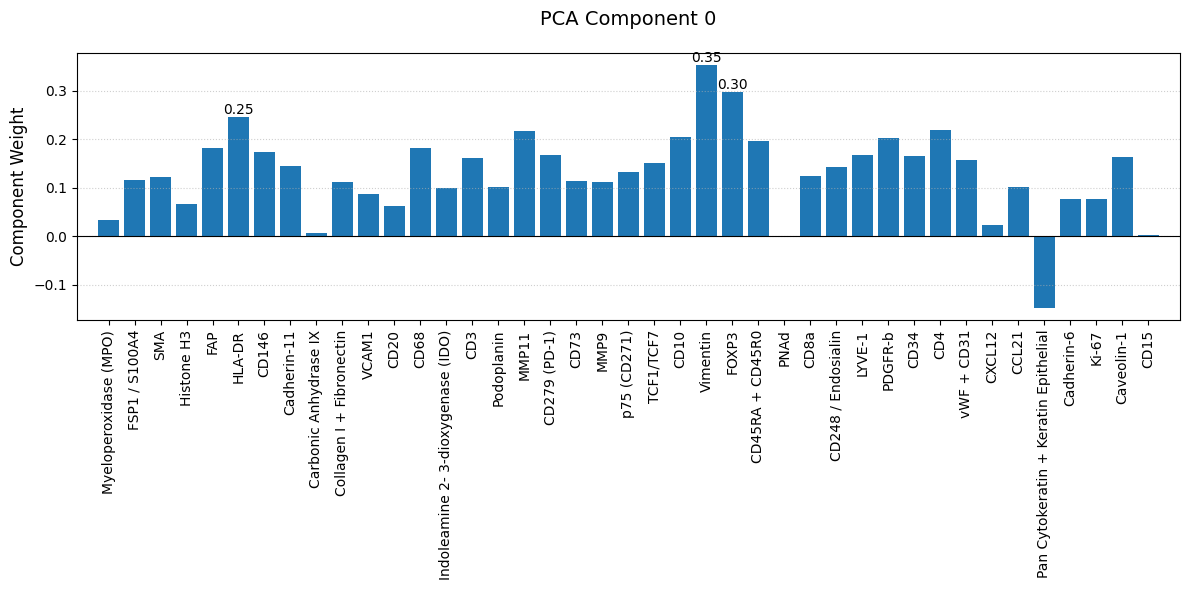

(41,)
41


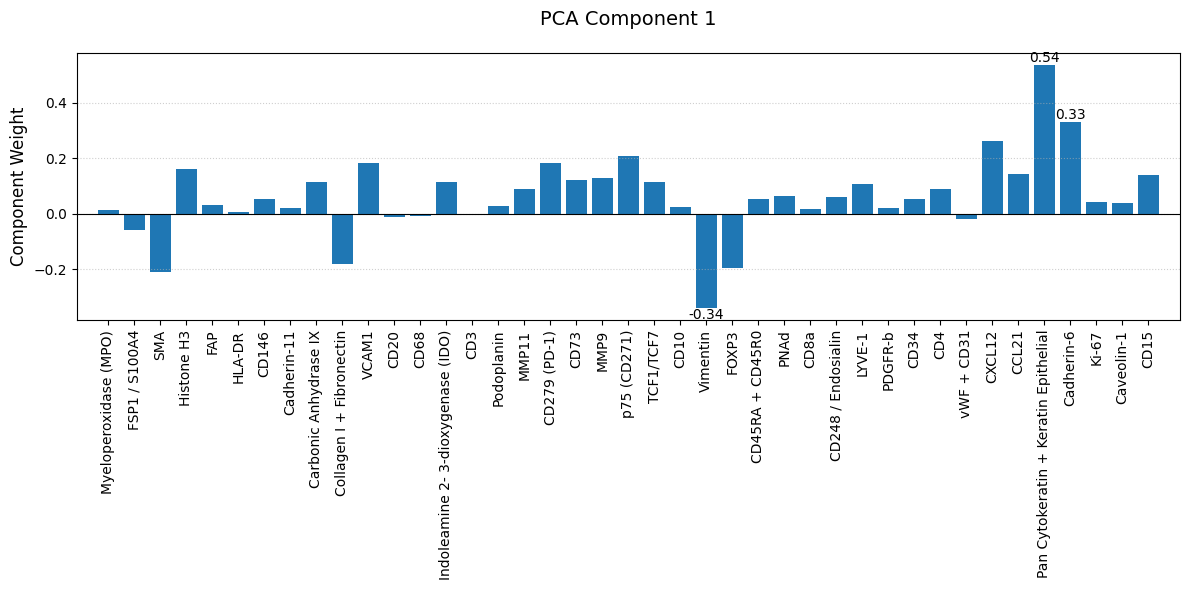

(41,)
41


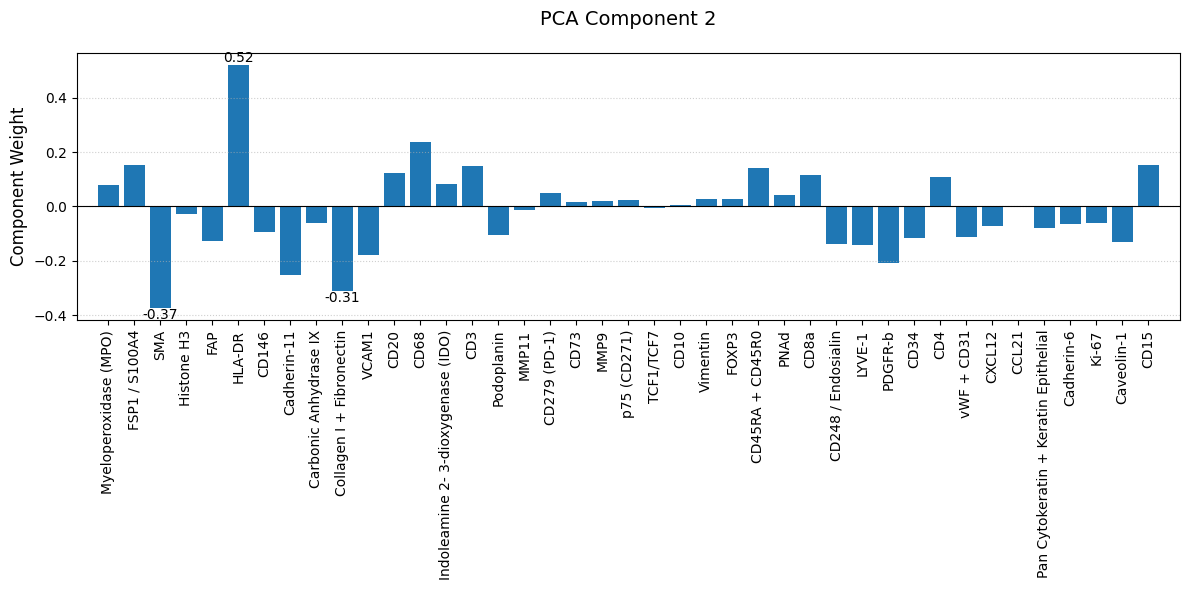

In [13]:
from joblib import load
pca = load('/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/pca_model_no_dna_normalized.joblib')
pca.components_
# Get channel names (assuming your original code works for this)
channel_map = list(df['Clean_Target'].dropna())
filtered_channel_map = [k for k in channel_map if "ridium" not in k]


# Create plots for each component
for k, comp in enumerate(pca.components_):
    plt.figure(figsize=(12, 6))
    
    # Create bar plot with proper channel labels
    x_pos = np.arange(len(filtered_channel_map))
    print(comp.shape)
    print(len(x_pos))
    bars = plt.bar(x_pos, comp)
    
    # Formatting to match box plot style
    plt.title(f"PCA Component {k}", fontsize=14, pad=20)
    plt.ylabel('Component Weight', fontsize=12)
    plt.xticks(x_pos, filtered_channel_map, rotation=90, ha='center', va='top', fontsize=10)
    
    # Add zero line and grid
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    # Adjust margins for labels
    plt.subplots_adjust(bottom=0.3)
    plt.margins(x=0.02)
    
    # Add value labels for top/bottom 3 features
    sorted_idx = np.argsort(np.abs(comp))[::-1]
    for i in sorted_idx[:3]:
        plt.text(x_pos[i], comp[i], f"{comp[i]:.2f}", 
                ha='center', va='bottom' if comp[i] > 0 else 'top')
    
    plt.tight_layout()
    plt.show()

subsample
(41, 20680)


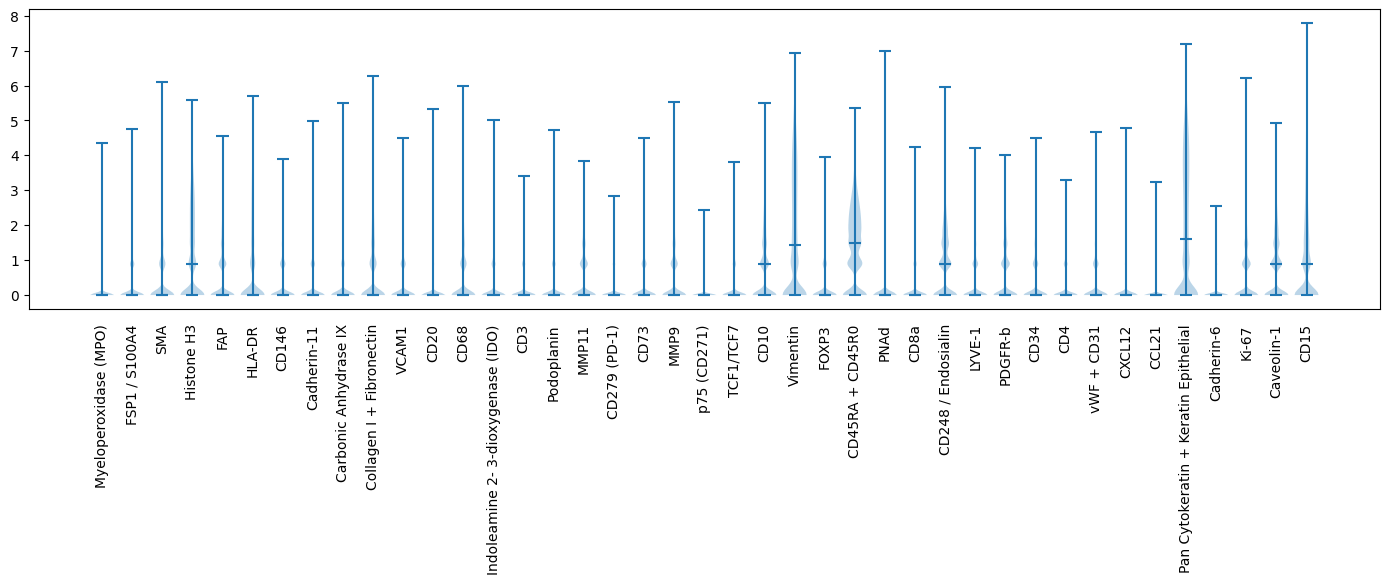

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming pixel_list is (n_features, n_datapoints)
# If it's (n_datapoints, n_features), transpose first:
# pixel_list = pixel_list.T  # Uncomment if needed

# Arcsinh transform
arcsinh_pixel_list = np.arcsinh(np.delete(pixel_list, (38, 39)  , axis=0))
arcsinh_pixel_list_subsampled = np.sort(arcsinh_pixel_list, axis=-1)[:, ::100]
print("subsample")
print(arcsinh_pixel_list_subsampled.shape)

# Create violin plot
plt.figure(figsize=(14, 6))

# Create violin plot
violin = plt.violinplot(
    arcsinh_pixel_list_subsampled.T, 
    widths=0.8, 
    showmeans=False, 
    showextrema=True, 
    showmedians=True
)

# Get current axes and y-axis limits
ax = plt.gca()
ymin, ymax = ax.get_ylim()

# Calculate positions for labels (1-based for violinplot)
x_pos = range(1, n_features + 1)

# Add labels BELOW each violin with text-right alignment
for x, label in zip(x_pos, [k for k in channel_map if "ridium" not in k]):
    ax.text(
        x=x,                          # X position (same as violin)
        y=ymin - 0.05 * (ymax - ymin),  # Slightly below the plot
        s=label,                       # Text label
        rotation=90,                   # Vertical text
        ha='center',                    # Right-aligns the text block itself
        va='top',                   # Centers vertically relative to position
        fontsize=10
    )

# Remove default x-ticks to avoid duplication
ax.set_xticks([])
ax.set_xticklabels([])

# Adjust bottom margin to prevent clipping
plt.subplots_adjust(bottom=0.2)  # Increase if labels are cut off

plt.tight_layout()
plt.show()

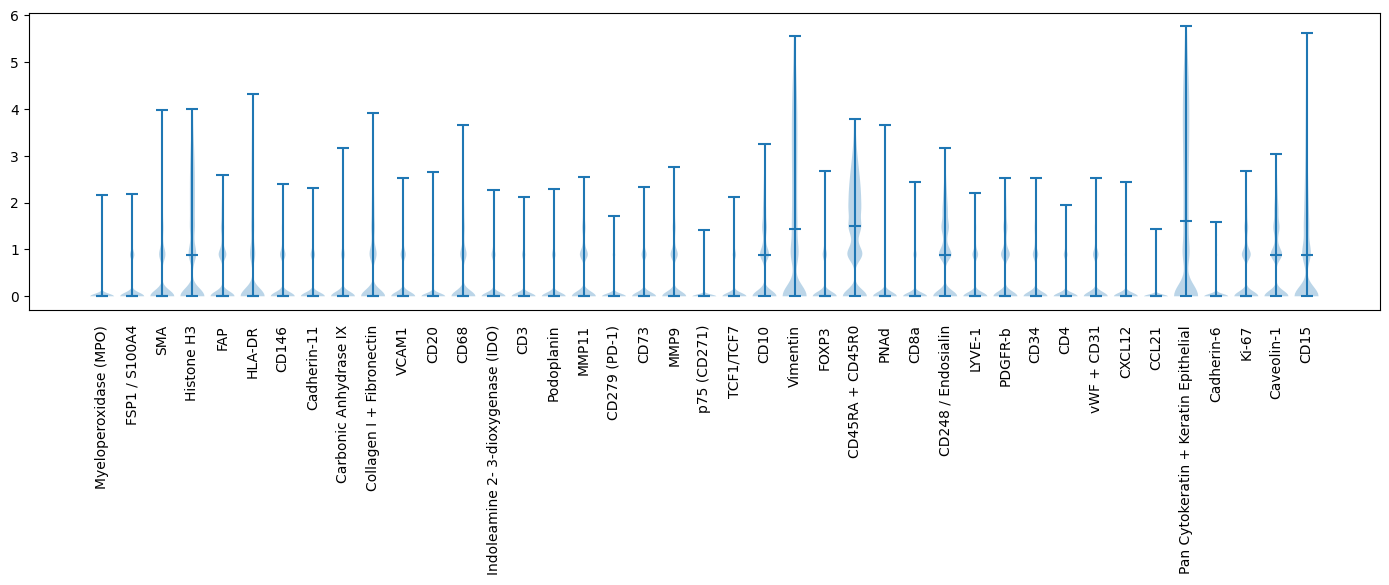

In [81]:
# Plot 2: Clipped data (using percentiles to remove extreme outliers)
clipped_arcsinh_pixel_list = np.zeros_like(arcsinh_pixel_list)
for dim in range(arcsinh_pixel_list.shape[0]):
    lower = np.percentile(arcsinh_pixel_list[dim], 0)
    upper = np.percentile(arcsinh_pixel_list[dim], 99)
    clipped_arcsinh_pixel_list[dim] = np.clip(arcsinh_pixel_list[dim], lower, upper)
clipped_arcsinh_pixel_list_subsampled = np.sort(clipped_arcsinh_pixel_list, axis=-1)[:, ::100]


# Create violin plot
plt.figure(figsize=(14, 6))

# Create violin plot
violin = plt.violinplot(
    clipped_arcsinh_pixel_list_subsampled.T, 
    widths=0.8, 
    showmeans=False, 
    showextrema=True, 
    showmedians=True
)

# Get current axes and y-axis limits
ax = plt.gca()
ymin, ymax = ax.get_ylim()

# Calculate positions for labels (1-based for violinplot)
x_pos = range(1, n_features + 1)

# Add labels BELOW each violin with text-right alignment
for x, label in zip(x_pos, [k for k in channel_map if "ridium" not in k]):
    ax.text(
        x=x,                          # X position (same as violin)
        y=ymin - 0.05 * (ymax - ymin),  # Slightly below the plot
        s=label,                       # Text label
        rotation=90,                   # Vertical text
        ha='center',                    # Right-aligns the text block itself
        va='top',                   # Centers vertically relative to position
        fontsize=10
    )

# Remove default x-ticks to avoid duplication
ax.set_xticks([])
ax.set_xticklabels([])

# Adjust bottom margin to prevent clipping
plt.subplots_adjust(bottom=0.2)  # Increase if labels are cut off

plt.tight_layout()
plt.show()

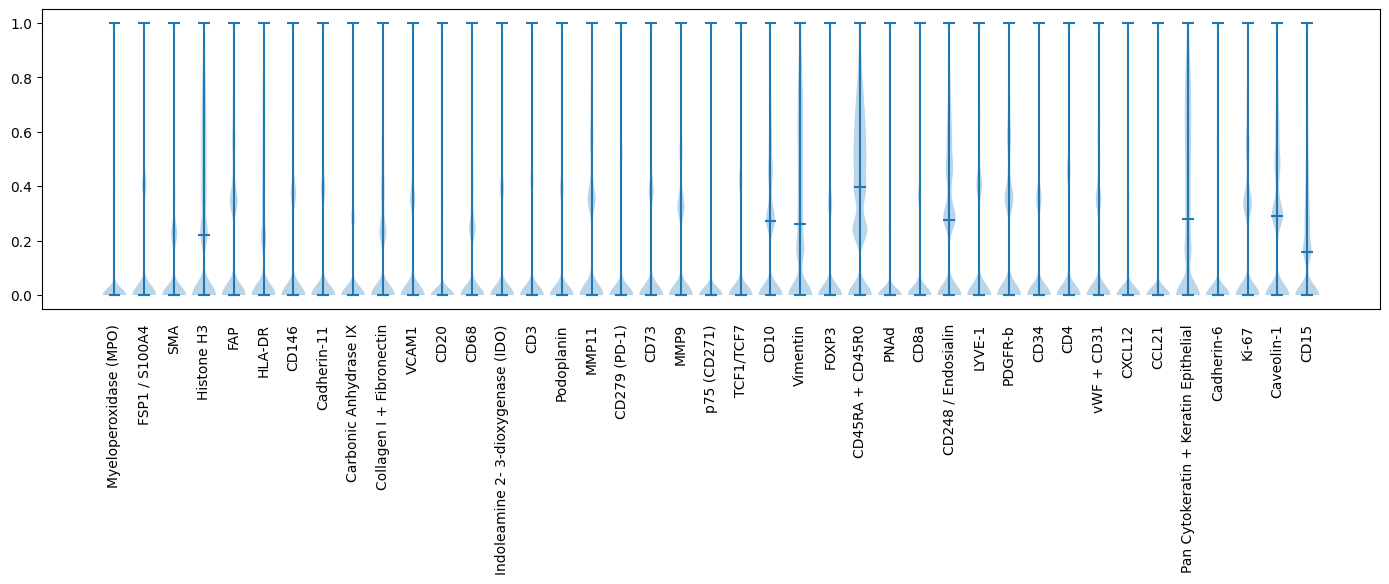

In [83]:
# Plot 3: Normalized clipped data
normed_clipped_arcsinh_pixel_list = np.zeros_like(arcsinh_pixel_list)
for dim in range(arcsinh_pixel_list.shape[0]):
    min_val = clipped_arcsinh_pixel_list[dim].min()
    max_val = clipped_arcsinh_pixel_list[dim].max()
    range_val = max_val - min_val
    # Handle case where all values are identical
    normed_clipped_arcsinh_pixel_list[dim] = ((clipped_arcsinh_pixel_list[dim] - min_val) / 
                                             (range_val if range_val > 0 else 1.0))
normed_clipped_arcsinh_pixel_list_subsampled = np.sort(normed_clipped_arcsinh_pixel_list, axis=-1)[:, ::100]

# Create violin plot
plt.figure(figsize=(14, 6))

# Create violin plot
violin = plt.violinplot(
    normed_clipped_arcsinh_pixel_list_subsampled.T, 
    widths=0.8, 
    showmeans=False, 
    showextrema=True, 
    showmedians=True
)

# Get current axes and y-axis limits
ax = plt.gca()
ymin, ymax = ax.get_ylim()

# Calculate positions for labels (1-based for violinplot)
x_pos = range(1, n_features + 1)

# Add labels BELOW each violin with text-right alignment
for x, label in zip(x_pos, [k for k in channel_map if "ridium" not in k]):
    ax.text(
        x=x,                          # X position (same as violin)
        y=ymin - 0.05 * (ymax - ymin),  # Slightly below the plot
        s=label,                       # Text label
        rotation=90,                   # Vertical text
        ha='center',                    # Right-aligns the text block itself
        va='top',                   # Centers vertically relative to position
        fontsize=10
    )

# Remove default x-ticks to avoid duplication
ax.set_xticks([])
ax.set_xticklabels([])

# Adjust bottom margin to prevent clipping
plt.subplots_adjust(bottom=0.2)  # Increase if labels are cut off

plt.tight_layout()
plt.show()

In [ ]:
mask_repeated = np.repeat(mask[np.newaxis, :, :], im.shape[0], axis=0).astype(np.uint32)
n = np.max(mask)  # n = 2

# Step 2: Offset labels per channel
offset_mask = np.zeros_like(mask_repeated, dtype=np.uint32)
for c in range(mask_repeated.shape[0]):
    offset_mask[c] = np.where(
        mask_repeated[c] > 0,
        mask_repeated[c] + (c * n),  # Offset labels
        0                            # Leave 0s unchanged
    )
offset_mask.shape
offset_mask.max()
# len(regionprops(mask_repeated, im))
# im.shape

In [ ]:
def get_aggregated_channel(im, mask, channel_idx):
    im_slice = im[channel_idx]
    regions = regionprops(mask, im_slice)
    
    # Create a lookup array (faster than dictionary for NumPy operations)
    max_label = np.max(mask)
    lookup = np.zeros(max_label + 1, dtype=np.float32)  # Index 0 unused (background)
    for region in regions:
        lookup[region.label] = region.mean_intensity
    
    # Vectorized lookup using the mask's labels
    aggregated_channel = np.where(
        mask > 0,
        lookup[mask],  # Direct array indexing
        0              # Leave 0s unchanged
    )
    return aggregated_channel

def get_aggregated_img(im, mask):
    aggregated_img = np.zeros_like(im)
    for channel in range(im.shape[0]):
        aggregated_img[channel] = get_aggregated_channel(im, mask, channel)
    return aggregated_img

def get_masked_img(im, mask):
    # applies mask to 
    mask = mask > 0
    mask = mask[None, ...]
    mask = mask.repeat(im.shape[0], axis=0)

    return mask * im 

agg_im = get_aggregated_img(im, mask)

In [ ]:
for k in range(43):
    plt.figure()
    plt.title(f"agg figure {k}")
    plt.imshow(agg_im[k])
    plt.colorbar()
    plt.figure()
    plt.title(f"orig figure {k}")
    plt.imshow(im[k])
    plt.colorbar()


In [65]:

import tifffile

from tqdm import tqdm

def get_dimensionality_reduction(from_aggregated=True, file_limit=None):
    def get_patient_id(img_path):
        # Convert Path object to string if needed
        img_path = str(img_path)
        return img_path.split("/")[-1].split(".")[0]
    
    # Define source directory based on the flag
    base_dir = Path('/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed')
    if from_aggregated:
        src_dir = base_dir / 'images/images_mcd_masked_averaged'
    else:
        src_dir = base_dir / 'images/images_mcd_masked'

    pixel_list = []
    
    # Check if directory exists
    if not src_dir.exists():
        raise FileNotFoundError(f"Directory not found: {src_dir}")
    
    # Iterate through image files in the directory
    file_count = 0 

    for image_path in tqdm(src_dir.glob('*.tiff')):  # assuming they're TIFF files
        if file_limit is not None:
            if file_count > file_limit:
                break

        try:
            image = tifffile.imread(image_path)
            patient_id = get_patient_id(image_path)  # pass image_path, not image
            mask = get_mask(patient_id).astype(np.uint32)  # assuming get_mask is defined elsewhere
            nonzero_indices = np.nonzero(mask)
            
            # Check if image and mask dimensions match
            if image.shape[1:] != mask.shape:
                raise ValueError(f"Image and mask dimensions don't match for {patient_id}")
            pixel_array = image[:, nonzero_indices[0], nonzero_indices[1]]
            pixel_array = np.delete(pixel_array, (38, 39), axis=0)
            pixel_list.append(pixel_array)
        except Exception as e:
            print(f"Error processing {image_path}: {str(e)}")
            continue

    return np.concatenate(pixel_list, axis=1)

pixel_list = get_dimensionality_reduction(from_aggregated=True)

50it [00:10,  4.69it/s]


KeyboardInterrupt: 

In [17]:
pixel_list = np.concatenate(pixel_list, axis=1)

In [61]:
import sys
sys.path.append("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial")
sys.path.append("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src")

from src.gnn_spatial.NSCLC.gen_pca import IRIDIUM_INDICES


def gen_pca_image(patient_id, output_dir, pca):
    patient_id = patient_id + ".tiff"
    img_pth = nsclc_path / 'images/images_mcd_masked' / patient_id
    image = tifffile.imread(img_pth)

    # if no dna for pca, no dna for output
    if pca.n_features_in_ == 41:
        image = np.delete(image, IRIDIUM_INDICES, axis=0)

    original_image_shape = image.shape
    image = image.reshape(image.shape[0], -1)
    new_image = pca.transform(image.T).T
    new_image = new_image.reshape((3, *original_image_shape[1:]))
    output_path = Path(output_dir) / Path(patient_id)
    tifffile.imwrite(output_path, new_image)

    return new_image
    
im = gen_pca_image('86_A_21', '/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/images/images_mcd_masked_averaged_pca', pca)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1218.9985..2532.299].


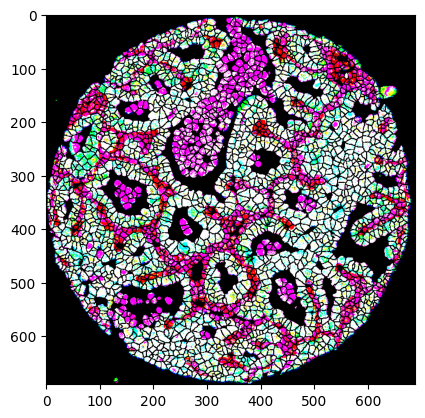

In [63]:
plt.figure()
masked_im = im * get_mask('86_A_21').astype(bool)
plt.imshow(np.transpose(masked_im, (1, 2, 0)))
# plt.imshow(get_mask('86_A_21')[..., np.newaxis].astype(bool))
plt.show()

In [14]:
import joblib
pca = joblib.load("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/pca_model_no_dna_normalized.joblib")
for img_pth in tqdm(Path('/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/images/images_mcd_masked').glob("*.tiff")):
    patient_id = str(img_pth).split("/")[-1].split(".")[0]
    gen_pca_image(patient_id, '/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/images/images_mcd_masked_normed_pca', pca)

0it [00:00, ?it/s]


NameError: name 'gen_pca_image' is not defined

In [42]:
import tifffile 

pth = '/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/images/images_mcd_masked_pca/175_A_121.tiff'
im = tifffile.imread(pth)
im.shape

plt.figure()
plt.imshow(np.transpose(im * get_mask(patient_id)[None, ...].astype(bool), (1, 2, 0)))

ValueError: operands could not be broadcast together with shapes (3,738,685) (1,736,633) 

<Figure size 640x480 with 0 Axes>

In [ ]:
adata = get_anndata("86_A_21")
adata.obs['DX.name']

In [65]:
with open('/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/train_tumor_typ_20250519.txt', "r") as file:
    train_ids = [line.strip().split("\t")[1] for line in file if line.strip()]

#with open('/users/tmaffei1/GNN_spatial/src/gnn_spatial/train/splits/val_tumor_typ_20250506.txt', "r") as file:
with open("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/val_tumor_typ_20250519.txt", "r") as file:
    val_ids = [line.strip().split("\t")[1] for line in file if line.strip()]

with open('/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/test_tumor_typ_20250519.txt', "r") as file:
    test_ids = [line.strip().split("\t")[1] for line in file if line.strip()]



In [ ]:
print(np.abs(pca.components_))

In [46]:
def gen_sliced_images(src_dir, patient_id, output_dir, model):
    image_path = src_dir / patient_id
    # im = 

In [ ]:
import tifffile
print(tifffile.imread("/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/images/images_mcd/87_A_49.tiff").shape)
print(tifffile.imread("/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/masks/20250430_cell_masks/87_A_49.tiff").shape)

In [ ]:
problems = ["175_B_90.tiff",
"176_B_47.tiff",
"176_C_2.tiff",
"178_B_57.tiff",
"86_B_1.tiff",
"87_A_49.tiff",
"88_A_10.tiff",
"88_A_9.tiff",
"88_B_110.tiff"]


for problem in problems:
    try:
        mask = tifffile.imread(f"/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/masks/20250430_cell_masks/{problem}")
        plt.figure()
        plt.imshow(mask)
    except Exception as e:
        print(e)

In [ ]:
for k in range(10, 30):
    plt.figure()
    plt.imshow(tifffile.imread("/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/images/images_mcd/175_B_90.tiff")[k])

In [13]:
def get_dimensionality_reduction(from_aggregated=True):
    def get_patient_id(img_path):
        # Convert Path object to string if needed
        img_path = str(img_path)
        return img_path.split("/")[-1].split(".")[0]
    
    # Define source directory based on the flag
    base_dir = Path('/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed')
    if from_aggregated:
        src_dir = base_dir / 'images/images_mcd_masked_averaged'
    else:
        src_dir = base_dir / 'images/images_mcd_masked'

    pixel_list = []
    
    # Check if directory exists
    if not src_dir.exists():
        raise FileNotFoundError(f"Directory not found: {src_dir}")
    
    # Iterate through image files in the directory
    for image_path in src_dir.glob('*.tiff'):  # assuming they're TIFF files
        try:
            image = tifffile.imread(image_path)
            patient_id = get_patient_id(image_path)  # pass image_path, not image
            mask = get_mask(patient_id).astype(np.uint32)  # assuming get_mask is defined elsewhere
            nonzero_indices = np.nonzero(mask)
            
            # Check if image and mask dimensions match
            if image.shape[1:] != mask.shape:
                raise ValueError(f"Image and mask dimensions don't match for {patient_id}")
                
            pixel_array = image[:, nonzero_indices[0], nonzero_indices[1]]
            pixel_list.append(pixel_array)
        except Exception as e:
            print(f"Error processing {image_path}: {str(e)}")
            continue


        
        


# What needs to work?

We need to basically be able to load batches with the id, patient id, an image tensor, and finally a label. 

In [ ]:
df_metadata

In [ ]:
with open("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/train_tumor_typ_20250519.txt", "r") as file:
    train_ids = [line.strip().split("\t")[1] for line in file.readlines()]
with open("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/val_tumor_typ_20250519.txt", "r") as file:
    val_ids = [line.strip().split("\t")[1] for line in file.readlines()]
# with open("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/test_tumor_typ_20250519.txt", "r") as file:
#     test_ids = [line.strip().split("\t")[1] for line in file.readlines()]


train_dataset = NsclcImageDataset(
    patient_ids_array=train_ids,
    should_average_mask=False
)

val_dataset = NsclcImageDataset(
    patient_ids_array=val_ids,
    should_average_mask=False
)

In [64]:
import os
import cv2
import tifffile

#TODO: get dataset level statistics.

def get_nsclc_preprocessing_dict():
    """
    metrics to compute: 
        - channel-wise mean
        - channel-wise stddev
        - channel-wise 0.5 percentile
        - channel-wise 99.5 percentile
    """
    # for each image in the dataset: 
    src_dir = Path('/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/images/images_mcd_masked_pca')

    pixel_list = []

    for patient_id in tqdm(train_dataset.data['patient_id']):
        patient_id_filename_tiff = patient_id + ".tiff"
        # read the image in to get (3, m, n) np array
        image_path_tiff = src_dir / patient_id_filename_tiff
        img = tifffile.imread(image_path_tiff)

        mask = get_mask(patient_id).astype(np.uint32)  # assuming get_mask is defined elsewhere
        nonzero_indices = np.nonzero(mask)
        
        # Check if image and mask dimensions match
        if img.shape[1:] != mask.shape:
            raise ValueError(f"Image and mask dimensions don't match for {patient_id}")
        pixel_array = img[:, nonzero_indices[0], nonzero_indices[1]]
        pixel_list.append(pixel_array)

    return pixel_list


def prepare_nsclc_files(dataset, is_train=True):
    src_dir = Path('/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/images/images_mcd_masked_pca')
    output_dir = Path(f'/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/datasets/nsclc/{"train" if is_train else "test"}_cropped')
    
    # with open("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/train_tumor_typ_20250519.txt", "r") as file:
    #     train_ids = [line.strip().split("\t")[1] for line in file.readlines()]
    # # with open("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/val_tumor_typ_20250519.txt", "r") as file:
    # #     val_ids = [line.strip().split("\t")[1] for line in file.readlines()]
    # # with open("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/GNN_spatial/src/gnn_spatial/train/splits/test_tumor_typ_20250519.txt", "r") as file:
    # #     test_ids = [line.strip().split("\t")[1] for line in file.readlines()]


    # train_dataset = NsclcImageDataset(
    #     patient_ids_array=train_ids,
    #     should_average_mask=False
    # )
    # iterate through the (train, val) ids
    # for each entry in self.data:
    for tumor_type, patient_id in tqdm(zip(dataset.data['tumor_type'], dataset.data['patient_id'])):
        patient_id_filename_tiff = patient_id + ".tiff"
        # read the image in to get (3, m, n) np array
        image_path_tiff = src_dir / patient_id_filename_tiff
        img = tifffile.imread(image_path_tiff)
        # save the image as a png in the appropriate directory
        image_cv2_format = np.transpose(process_img(img, stats_dict) * get_mask(patient_id)[None, ...].astype(bool), (1, 2, 0)) * 255.
        patient_id_filename_png = patient_id + ".png"
        type_specific_output_dir = output_dir / tumor_type.replace(" ", "_")
        os.makedirs(type_specific_output_dir, exist_ok=True)
        # if type_specific_output
        image_path_png = type_specific_output_dir / patient_id_filename_png
        cv2.imwrite(image_path_png, cv2.cvtColor(image_cv2_format, cv2.COLOR_BGR2RGB))

# prepare_nsclc_files(train_dataset, is_train=True)
# prepare_nsclc_files(val_dataset, is_train=False)

In [ ]:
pixel_array = np.concatenate(pixel_list, axis=1)

print("computing percentiles...")
pp_005 = np.percentile(pixel_array, 0.5, axis=1)
pp_995 = np.percentile(pixel_array, 99.5, axis=1)

print("clipping...")
for ch in range(pixel_array.shape[0]):
    pixel_array[ch] = np.clip(pixel_array[ch], pp_005[ch], pp_995[ch])

print("removing min...")
ch_min = pixel_array.min(axis=1)
pixel_array = pixel_array - ch_min[..., None] + 1e-9
pixel_array[0] = np.log(1 + pixel_array[0])

print("computing min and max at end...")
ch_log_norm_min = pixel_array.min(axis=1)
ch_log_norm_max = pixel_array.max(axis=1)
ch_log_norm_std = pixel_array.std(axis=1)
ch_log_norm_mean = pixel_array.mean(axis=1)

stats_dict = {
    "pp_005": pp_005,
    "pp_995": pp_995,
    "ch_min": ch_min, 
    "ch_log_norm_min": ch_log_norm_min,
    "ch_log_norm_max": ch_log_norm_max,
    "ch_log_norm_std": ch_log_norm_std,
    "ch_log_norm_mean": ch_log_norm_mean,
}

stats_dict

In [ ]:
stats_dict

In [ ]:
stats_dict

In [ ]:
pixel_list = get_nsclc_preprocessing_dict()

In [ ]:
pixel_list[0].shape

In [ ]:
import tifffile
import cv2

src_dir = Path('/work/FAC/FBM/DBC/mrapsoma/prometex/data/NSCLC/02_processed/images/images_mcd_masked_pca')
output_dir = Path('/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/datasets/nsclc/test_cropped')

count, final_count = 0, 3

for patient_id in tqdm(val_dataset.data['patient_id']):
    patient_id_filename_tiff = patient_id + ".tiff"
    # read the image in to get (3, m, n) np array
    image_path_tiff = src_dir / patient_id_filename_tiff
    img = tifffile.imread(image_path_tiff)
    # save the image as a png in the appropriate directory
    image_cv2_format = np.transpose(process_img(img) * get_mask(patient_id)[None, ...].astype(bool), (1, 2, 0))
    patient_id_filename_png = patient_id + ".png"
    image_path_png = output_dir / patient_id_filename_png
    rgb_image = cv2.cvtColor(image_cv2_format, cv2.COLOR_BGR2RGB)
    break
    count += 1
    if final_count == count:
        break
    

In [ ]:
patient_id = '86_A_21'
patient_id_filename_tiff = patient_id + ".tiff"
# read the image in to get (3, m, n) np array
image_path_tiff = src_dir / patient_id_filename_tiff
img = tifffile.imread(image_path_tiff)

print(patient_id)


def drop_mode_with_tolerance(arr, tol=1e-9):
    # Find the mode (most frequent value)
    values, counts = np.unique(arr, return_counts=True)
    mode = values[np.argmax(counts)]
    
    # Create a mask where values are NOT approximately equal to the mode (within tolerance)
    mask = ~np.isclose(arr, mode, atol=tol)
    
    # Return the filtered array
    return arr[mask]

def process_img(img, stats_dict):
    processed_img = np.zeros_like(img)
    
    for ch in range(img.shape[0]):
        # processed_img[ch] = img[ch] - drop_mode_with_tolerance(img[ch]).min() + 1e-9
        processed_img[ch] = np.clip(img[ch], stats_dict['pp_005'][ch], stats_dict['pp_995'][ch])
        processed_img[ch] = processed_img[ch] - stats_dict['ch_min'][ch] + 1e-9

    processed_img[0] = np.log(1 + processed_img[0])

    for ch in range(img.shape[0]):
        # ch_mean, ch_std = drop_mode_with_tolerance(processed_img[ch]).mean(), drop_mode_with_tolerance(processed_img[ch]).std()
        # processed_img[ch] = (((processed_img[ch] - ch_mean) / ch_std))
        # processed_img[ch] = np.clip(processed_img[ch], np.percentile(drop_mode_with_tolerance(processed_img[ch]), 0.5), np.percentile(drop_mode_with_tolerance(processed_img[ch]), 99.5))
        # processed_img[ch] = (processed_img[ch] - stats_dict['ch_log_norm_min'][ch]) / (stats_dict['ch_log_norm_max'][ch] - stats_dict['ch_log_norm_min'][ch])
        processed_img[ch] = (processed_img[ch] - stats_dict['ch_log_norm_mean'][ch]) / (stats_dict['ch_log_norm_std'][ch] * 3)

    return processed_img

In [ ]:
plt.figure()
# plt.imshow(np.transpose(process_img(img), (1, 2, 0)) * get_mask(patient_id)[..., None].astype(bool))
plt.imshow(np.transpose(process_img(img, stats_dict), (1, 2, 0)) * get_mask(patient_id)[..., None].astype(bool))
for k in range(3): 
    print((np.transpose(process_img(img, stats_dict), (1, 2, 0)) * get_mask(patient_id)[..., None].astype(bool))[:,:,k].min())
    print((np.transpose(process_img(img, stats_dict), (1, 2, 0)) * get_mask(patient_id)[..., None].astype(bool))[:,:,k].max())



In [ ]:
# def drop_mode_with_tolerance(arr, tol=1e-9):
#     # Find the mode (most frequent value)
#     values, counts = np.unique(arr, return_counts=True)
#     mode = values[np.argmax(counts)]
    
#     # Create a mask where values are NOT approximately equal to the mode (within tolerance)
#     mask = ~np.isclose(arr, mode, atol=tol)
    
#     # Return the filtered array
#     return arr[mask]

for k in range(img.shape[0]):
    plt.figure()
    data = process_img(img, stats_dict)[k].flatten()
    plt.hist(drop_mode_with_tolerance(data), bins=100)


In [ ]:
data.mode()

In [ ]:
for k in range(img.shape[0]):
    plt.figure()
    # Get the flattened image data
    data = process_img(img, stats_dict)[k] * get_mask(patient_id).flatten()
    # Calculate the 99th percentile
    p1 = np.percentile(data, 1)
    p5 = np.percentile(data, 5)
    p95 = np.percentile(data, 95)
    p99 = np.percentile(data, 99)
    # Plot histogram with clipped range
    plt.hist(data, bins=100)
    # Optional: Add a vertical line to show where the clipping occurs
    plt.axvline(p99, color='r', linestyle='dashed', linewidth=1)
    plt.title(f'Slice {k} - Values clipped at 99th percentile ({p99:.2f})')
    print(f"Min: {data.min()}")
    print(f"1: {p1}")
    print(f"5: {p5}")
    print(f"95: {p95}")
    print(f"99: {p99}")
    print(f"Max: {data.max()}")

# Post Hoc Analysis

In [4]:
import sys
sys.path.append("/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet")
import torch

from settings import base_architecture, num_classes, train_batch_size, train_push_batch_size, img_size, prototype_shape, prototype_activation_function, add_on_layers_type, ablate_prototype_selection
import model
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# load dataloader
train_dir = "/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/datasets/nsclc/train_normed_cropped"
train_push_dir = train_dir

train_dataset = datasets.ImageFolder(
    train_dir,
    transforms.Compose([
        transforms.Resize(size=(img_size, img_size)),
        transforms.RandomRotation(degrees=(-180, 180)),
        transforms.ToTensor(),
        # normalize,
    ]))
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=train_batch_size, shuffle=True,
    num_workers=1, pin_memory=False)
# push set
train_push_dataset = datasets.ImageFolder(
    train_push_dir,
    transforms.Compose([
        transforms.Resize(size=(img_size, img_size)),
        transforms.ToTensor(),
    ]))
train_push_loader = torch.utils.data.DataLoader(
    train_push_dataset, batch_size=train_push_batch_size, shuffle=False,
    num_workers=1, pin_memory=False)

state_dict_path = "/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/saved_models/resnet152/electric-deluge-9/60_9push0.8037.pth"
ppnet = torch.load(state_dict_path, map_location='cuda', weights_only=False)  # Add map_location if needed


DeferredCudaCallError: CUDA call failed lazily at initialization with error: device >= 0 && device < num_gpus INTERNAL ASSERT FAILED at "/pytorch/aten/src/ATen/cuda/CUDAContext.cpp":52, please report a bug to PyTorch. device=1, num_gpus=1

CUDA call was originally invoked at:

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asy

In [20]:
torch.cuda.is_available()

True

In [21]:
import push
from importlib import reload
reload(push)

<module 'push' from '/work/FAC/FBM/DBC/mrapsoma/prometex/projects/ProtoPNet/push.py'>

In [13]:
push.find_k_closest_per_prototype(
    dataloader=train_push_loader,
    prototype_network=ppnet,
    k=20
)

DeferredCudaCallError: CUDA call failed lazily at initialization with error: device >= 0 && device < num_gpus INTERNAL ASSERT FAILED at "../aten/src/ATen/cuda/CUDAContext.cpp":49, please report a bug to PyTorch. device=1, num_gpus=

CUDA call was originally invoked at:

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_l